# Lecture 04 — Statistics & Data Visualization for Data Analysis
### Implementation Notebook

Welcome back! You can already load, clean, and reshape data with Pandas. Today's question is
different: **once your data is clean, what does it actually tell you?**

That's what statistics and visualization are for. Every number we compute today, and every chart
we draw, answers one of a small number of real analyst questions:
- "What's typical here?" → central tendency
- "How spread out is it?" → spread, quartiles
- "What shape does it have?" → distribution
- "What doesn't belong?" → outliers
- "How do I *show* someone this, not just tell them?" → visualization

**Notebook objectives** — by the end of today you'll be able to:
- Tell numerical vs. categorical, continuous vs. discrete, nominal vs. ordinal data apart
- Compute and correctly choose between mean, median, and mode
- Compute and interpret variance, standard deviation, quartiles, and the IQR
- Recognize symmetric, right-skewed, and left-skewed distributions
- Detect outliers with both the IQR method and the Z-score method
- Build the core chart types in both Matplotlib and Seaborn — and **read** them like an analyst,
  not just produce them
- Apply every one of these skills, independently, to the real Titanic dataset

**How today works**
- Every concept follows the same rhythm: **small example → live coding → Titanic example →
  your turn → discussion → checkpoint.**
- Try to **predict** each output before running the cell — that's where the real learning
  happens, not in watching the answer appear.
- We are **not** doing full Exploratory Data Analysis (EDA) today — that's next lecture. Today
  is about understanding data statistically and visually, one number and one chart at a time.

**No review of Python, NumPy, or Pandas today** — we're assuming all of that is solid, and moving
straight into new material.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

print("numpy version      :", np.__version__)
print("pandas version     :", pd.__version__)
print("matplotlib version :", plt.matplotlib.__version__)
print("seaborn version    :", sns.__version__)
print("Ready to go!")

numpy version      : 2.4.6
pandas version     : 3.0.3
matplotlib version : 3.11.0
seaborn version    : 0.13.2
Ready to go!


### Loading today's two datasets

**Employees** — our small teaching dataset (10 rows), used to build intuition for every new idea
before we touch real data. It has one deliberate high earner (`Hossam`) — useful later, when we
look at how outliers distort statistics.

**Titanic** — the real dataset (891 passengers) we'll gradually apply every concept to,
throughout the second half of the notebook.

In [2]:
employees = pd.DataFrame({
    "Name": ["Sara", "Omar", "Lina", "Mostafa", "Nourhan",
             "Khaled", "Rana", "Ahmed", "Salma", "Hossam"],
    "Department": ["IT", "Sales", "IT", "HR", "Marketing",
                   "Sales", "IT", "HR", "Marketing", "IT"],
    "Salary": [9000, 7000, 8500, 6200, 7800, 7200, 9500, 6000, 8100, 32000],
    "YearsExperience": [5, 2, 4, 3, 6, 1, 7, 2, 5, 15],
    "City": ["Cairo", "Alexandria", "Cairo", "Giza", "Cairo",
             "Alexandria", "Alexandria", "Giza", "Cairo", "Cairo"],
    "PerformanceScore": [88, 75, 91, 80, 90, 65, 95, 70, 82, 97],
})
employees

,Name,Department,Salary,YearsExperience,City,PerformanceScore
0,Sara,IT,9000,5,Cairo,88
1,Omar,Sales,7000,2,Alexandria,75
2,Lina,IT,8500,4,Cairo,91
3,Mostafa,HR,6200,3,Giza,80
4,Nourhan,Marketing,7800,6,Cairo,90
5,Khaled,Sales,7200,1,Alexandria,65
6,Rana,IT,9500,7,Alexandria,95
7,Ahmed,HR,6000,2,Giza,70
8,Salma,Marketing,8100,5,Cairo,82
9,Hossam,IT,32000,15,Cairo,97


In [3]:
titanic = pd.read_csv("data/titanic.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
## 2. Understanding Data Types

Before computing anything, you need to know **what kind of column you're looking at** — the
right statistic (and the right chart) depends entirely on this.

### Numerical vs. Categorical
- **Numerical** — actual measured/counted quantities. `Salary`, `Age`, `Fare`.
- **Categorical** — a label from a limited set of groups. `Department`, `City`, `Sex`.

### Continuous vs. Discrete (both are numerical)
- **Continuous** — can take *any* value in a range, including fractions. `Salary`, `Fare`,
  `Age` (technically continuous, even though we usually record it in whole years).
- **Discrete** — only specific, usually whole-number, values. `YearsExperience`, `SibSp` (number
  of siblings/spouses aboard) — you can't have 2.5 years of experience or 1.5 siblings.

### Nominal vs. Ordinal (both are categorical)
- **Nominal** — categories with **no inherent order**. `Department` (IT isn't "more" than
  Sales), `City`, `Sex`.
- **Ordinal** — categories with a **real, meaningful order**. `Pclass` in the Titanic data
  (1st class ranks above 2nd, which ranks above 3rd) is a textbook example.

Let's classify every column in both datasets, live.

In [4]:
employees.dtypes

Name                  str
Department            str
Salary              int64
YearsExperience     int64
City                  str
PerformanceScore    int64
dtype: object

`dtypes` tells you the **storage** type (`int64`, `object`, ...) — not the *statistical* type
we just defined. `Department` and `City` are stored as `object` (text) and are also
**categorical, nominal**. `Salary` is stored as `int64` and is **numerical, continuous** (even
though every value in our small table happens to be a whole number — salaries in general can take
fractional values). This distinction — storage type vs. statistical type — trips people up
constantly, so it's worth sitting with.

In [5]:
titanic[["Pclass", "Sex", "Age", "SibSp", "Fare", "Survived"]].dtypes

Pclass        int64
Sex             str
Age         float64
SibSp         int64
Fare        float64
Survived      int64
dtype: object

**Titanic classification, worked through together:**
- `Pclass` — stored as a number, but statistically it's **categorical, ordinal** (1st > 2nd >
  3rd class in status, even though we'd never average it meaningfully).
- `Sex` — **categorical, nominal**.
- `Age` — **numerical, continuous**.
- `SibSp` — **numerical, discrete** (a count).
- `Fare` — **numerical, continuous**.
- `Survived` — stored as `0`/`1`, but statistically it's **categorical, nominal** (a "did/didn't"
  label, even though it's tempting to treat it like a number since it's stored as one — this is
  the same `Pclass` trap in reverse).

### 🏋️ Student Practice
For each of the following Titanic columns, classify it as
(numerical-continuous / numerical-discrete / categorical-nominal / categorical-ordinal), with one
sentence of reasoning each: `Parch`, `Embarked`, `Cabin`, `Ticket`.

In [6]:
# Your answers here (as comments, or edit this cell's type to Markdown)





### Population vs. Sample

- **Population** — the *complete* group you actually want to understand (e.g., every passenger who has ever sailed on an ocean liner).
- **Sample** — the subset you actually collected and can compute on (e.g., the 891 passengers in `titanic`).

This distinction matters because it changes what a statistic *means*: a sample mean is an **estimate** of the true population mean, not the population mean itself — and different samples give slightly different estimates. `titanic` is a sample, not the population.

In [7]:
np.random.seed(1)

full_ages = titanic["Age"].dropna()          # our best available "population" for this exercise
print("Full dataset  -- n:", len(full_ages), "| mean age:", full_ages.mean().round(2))

for trial in range(3):
    small_sample = full_ages.sample(30, random_state=trial)
    print(f"Sample of 30  -- n: {len(small_sample)} | mean age: {small_sample.mean():.2f}")

Full dataset  -- n: 714 | mean age: 29.7
Sample of 30  -- n: 30 | mean age: 30.21
Sample of 30  -- n: 30 | mean age: 30.15
Sample of 30  -- n: 30 | mean age: 33.12


Notice the three sample means above are all *close* to the full-dataset mean, but none of them match it exactly — that gap is **sampling variability**, and it's why we say a sample statistic is an *estimate*, not a fact about the population. Larger, more representative samples generally estimate the population value more reliably.

### ✅ Checkpoint
- Data type drives statistic choice: you can compute a mean of `Fare`, but a mean of `Sex` is
  meaningless. Storage type (`dtypes`) and statistical type are related but not the same thing —
  `Pclass` and `Survived` are the classic examples of numbers that are secretly categorical.
- The dataset itself is a **sample**, not a population — every mean, median, and std you compute
  from `titanic` is an *estimate* of the true ocean-liner-passenger population, not the exact
  population value.

---
## 3. Measures of Central Tendency

**The question:** *"What's a typical value in this column?"* There are three common answers, and
they don't always agree.

### Mean, median, mode — on a tiny example first

In [8]:
tiny = pd.Series([10, 12, 12, 13, 15])

print("mean  :", tiny.mean())
print("median:", tiny.median())
print("mode  :", tiny.mode().tolist())    # mode() can return MULTIPLE values -- ties are possible

mean  : 12.4
median: 12.0
mode  : [12]


### How outliers distort each measure

Let's add one extreme value to `tiny` and watch what happens to each statistic.

In [9]:
tiny_with_outlier = pd.Series([10, 12, 12, 13, 15, 500])   # one huge outlier added

print("Without outlier -> mean:", tiny.mean(), "| median:", tiny.median())
print("With outlier    -> mean:", tiny_with_outlier.mean(), "| median:", tiny_with_outlier.median())

Without outlier -> mean: 12.4 | median: 12.0
With outlier    -> mean: 93.66666666666667 | median: 12.5


**The mean jumped from ~12.4 to ~93.7 — one value dragged it wildly off.** The median barely
moved (12 → 12.5), because it only cares about *position*, not magnitude. This is the single most
important intuition in this section: **the median resists outliers, the mean does not.**

### Now on real data — Employees `Salary`

In [10]:
print("Salary mean  :", employees["Salary"].mean())
print("Salary median:", employees["Salary"].median())
print("Salary mode  :", employees["Salary"].mode().tolist())

Salary mean  : 10130.0
Salary median: 7950.0
Salary mode  : [6000, 6200, 7000, 7200, 7800, 8100, 8500, 9000, 9500, 32000]


### 🔮 Predict the Output
`Hossam`'s salary (32000) is far above everyone else's (6000–9500). Before running the next cell:
do you expect the mean or the median to better represent a "typical" employee's salary here?

In [11]:
print("Mean salary  :", employees['Salary'].mean())
print("Median salary:", employees['Salary'].median())
print()
print("9 out of 10 employees earn between 6000 and 9500 -- which statistic reflects that better?")

Mean salary  : 10130.0
Median salary: 7950.0

9 out of 10 employees earn between 6000 and 9500 -- which statistic reflects that better?


If you predicted the **median** better represents "typical" — that's the point. The mean
(~10,130) is pulled well above where 9 of the 10 employees actually sit, purely because of one
outlier. This is exactly why salary reports in the real world often quote the *median* salary,
not the average.

### On Titanic — `Fare`

In [12]:
print("Fare mean  :", titanic["Fare"].mean().round(2))
print("Fare median:", titanic["Fare"].median())
print("Fare mode  :", titanic["Fare"].mode().tolist())

Fare mean  : 32.2
Fare median: 14.4542
Fare mode  : [8.05]


The gap between Titanic's `Fare` mean (~32.2) and median (14.45) is a strong hint on its own,
before we've even drawn a chart, that `Fare` is skewed by a handful of very expensive tickets —
something we'll confirm visually in Section 6.

### 🏋️ Student Practice
1. Compute mean, median, and mode of `PerformanceScore` in `employees`.
2. Compute mean, median, and mode of `Age` in `titanic` (watch out — `Age` has missing values;
   does `.mean()` handle that automatically, or do you need to do something first? Check the
   result against `titanic["Age"].isnull().sum()` to reason about it).
3. In one sentence: for `Age`, are mean and median close together or far apart? What does that
   suggest, compared to the gap we just saw in `Fare`?

In [13]:
# Your code here





### 🔥 Challenge Question
Construct a 5-number `Series` where the **mean, median, and mode are all exactly equal**. Then
construct a second 5-number `Series` where all three are **different**. What does the first
series' shape probably look like, just from those three numbers agreeing?

In [14]:
# Your code here


### ✅ Checkpoint
- Mean = arithmetic average, sensitive to outliers. Median = the middle value, resistant to
  outliers. Mode = most frequent value(s), the only one of the three that also works on
  categorical data. When mean and median disagree noticeably, that's a signal the data might be
  skewed — before you've even plotted it.

---
## 4. Measures of Spread

**The question:** *"Two datasets can have the exact same average — how do I tell them apart?"*
Central tendency alone can hide very different realities.

### Same mean, different spread — the classic demonstration

In [15]:
team_a = pd.Series([48, 49, 50, 51, 52])       # tightly clustered around 50
team_b = pd.Series([10, 30, 50, 70, 90])       # wildly spread out, but ALSO averages to 50

print("Team A mean:", team_a.mean(), "| Team B mean:", team_b.mean())
print("Identical means -- but are these two teams equally consistent?")

Team A mean: 50.0 | Team B mean: 50.0
Identical means -- but are these two teams equally consistent?


### `min()`, `max()`, and range

In [16]:
print("Team A -- min:", team_a.min(), "max:", team_a.max(), "range:", team_a.max() - team_a.min())
print("Team B -- min:", team_b.min(), "max:", team_b.max(), "range:", team_b.max() - team_b.min())

Team A -- min: 48 max: 52 range: 4
Team B -- min: 10 max: 90 range: 80


### `var()` and `std()` — the real measures of spread

Range only looks at the two extremes. **Variance** and **standard deviation** account for
*every* value's distance from the mean.

In [17]:
print("Team A -- var:", team_a.var().round(2), "| std:", team_a.std().round(2))
print("Team B -- var:", team_b.var().round(2), "| std:", team_b.std().round(2))

Team A -- var: 2.5 | std: 1.58
Team B -- var: 1000.0 | std: 31.62


Team B's standard deviation is roughly **9x** larger than Team A's, even though both teams
average exactly 50. **Standard deviation is in the same units as your original data** (which is
why it's usually easier to interpret than variance, its squared cousin) — "Team B typically
deviates from 50 by about 31.6 points; Team A typically deviates by about 3.5."

### On real data — Employees `Salary` vs. a hypothetical "flat" company

In [18]:
flat_company_salaries = pd.Series([7500, 7600, 7400, 7550, 7450, 7500, 7480, 7520, 7510, 7490])

print("Our employees -- mean:", employees['Salary'].mean().round(0), "| std:", employees['Salary'].std().round(0))
print("Flat company  -- mean:", flat_company_salaries.mean().round(0), "| std:", flat_company_salaries.std().round(0))

Our employees -- mean: 10130.0 | std: 7768.0
Flat company  -- mean: 7500.0 | std: 54.0


### On Titanic — `Age` vs. `Fare`

In [19]:
print("Age  -- mean:", titanic['Age'].mean().round(1), "| std:", titanic['Age'].std().round(1))
print("Fare -- mean:", titanic['Fare'].mean().round(1), "| std:", titanic['Fare'].std().round(1))

Age  -- mean: 29.7 | std: 14.5
Fare -- mean: 32.2 | std: 49.7


Notice `Fare`'s standard deviation (~49.7) is actually **larger than its own mean** (~32.2) —
a strong numeric hint of heavy skew and outliers, which we'll see clearly once we visualize it.

### 🏋️ Student Practice
1. Compute `range`, `var()`, and `std()` for `YearsExperience` in `employees`.
2. Compute `std()` for `Fare` **grouped by `Pclass`** (hint: `groupby` + `.std()`, straight from
   Lecture 03) — which class has the most variable fares? Does that surprise you?

In [20]:
# Your code here





### ✅ Checkpoint
- `min()`/`max()`/range give a quick, crude sense of spread. `var()` and `std()` are the real
  measures — they account for every point, not just the extremes, and `std()` stays in your
  original units. Two datasets can share a mean and still describe very different realities.

---
## 5. Quartiles & Position Measures

**The question:** *"Give me more detail than just the middle — where do the bottom 25% and top
25% actually fall?"* Quartiles cut sorted data into four equal-sized chunks.

### `quantile()` on a small example

In [21]:
tiny_scores = pd.Series([55, 60, 65, 70, 72, 75, 78, 80, 85, 90])

q1 = tiny_scores.quantile(0.25)
q2 = tiny_scores.quantile(0.50)   # same as .median()
q3 = tiny_scores.quantile(0.75)

print("Q1 (25th percentile):", q1)
print("Q2 (50th percentile):", q2, "-- same as median:", tiny_scores.median())
print("Q3 (75th percentile):", q3)

Q1 (25th percentile): 66.25
Q2 (50th percentile): 73.5 -- same as median: 73.5
Q3 (75th percentile): 79.5


### The IQR — Interquartile Range

`IQR = Q3 - Q1` — the width of the "middle 50%" of your data. It's the foundation of one of the
two outlier-detection methods we'll use in Section 7.

In [22]:
iqr = q3 - q1
print("IQR:", iqr)
print("The middle 50% of scores span a range of", iqr, "points.")

IQR: 13.25
The middle 50% of scores span a range of 13.25 points.


### Percentiles — the general version

A quartile is just a percentile at 25%, 50%, or 75%. You can ask for *any* percentile.

In [23]:
p10 = tiny_scores.quantile(0.10)
p90 = tiny_scores.quantile(0.90)
print("10th percentile:", p10, "-- 10% of scores fall below this")
print("90th percentile:", p90, "-- 90% of scores fall below this")

10th percentile: 59.5 -- 10% of scores fall below this
90th percentile: 85.5 -- 90% of scores fall below this


### The five-number summary

`min, Q1, median, Q3, max` — five numbers that compactly describe an entire distribution's shape
and spread. This is also exactly what a box plot visualizes (Section 8).

In [24]:
def five_number_summary(series):
    return pd.Series({
        "min": series.min(),
        "Q1": series.quantile(0.25),
        "median": series.median(),
        "Q3": series.quantile(0.75),
        "max": series.max(),
    })

five_number_summary(tiny_scores)

min       55.00
Q1        66.25
median    73.50
Q3        79.50
max       90.00
dtype: float64

Notice this is almost exactly what `.describe()` (Lecture 03) gives you — `.describe()` is
really just the five-number summary plus `count`, `mean`, and `std` bundled together.

### On real data — Employees `Salary`

In [25]:
five_number_summary(employees["Salary"])

min        6000.0
Q1         7050.0
median     7950.0
Q3         8875.0
max       32000.0
dtype: float64

Look at the gap between `Q3` (8875) and `max` (32000) — much bigger than the gap between
`min` and `Q1`. That asymmetry is a numeric preview of the right-skew we'll see plotted in
Section 6.

### On Titanic — `Fare` and `Age`

In [26]:
print("Fare five-number summary:")
print(five_number_summary(titanic["Fare"]))
print()
print("Age five-number summary:")
print(five_number_summary(titanic["Age"]))

Fare five-number summary:
min         0.0000
Q1          7.9104
median     14.4542
Q3         31.0000
max       512.3292
dtype: float64

Age five-number summary:
min        0.420
Q1        20.125
median    28.000
Q3        38.000
max       80.000
dtype: float64


### 🔮 Predict the Output
Given `Fare`'s Q3 is around 31 but its max is over 512 — do you expect `Fare`'s mean to sit
closer to its median, or noticeably above it? (You already computed both in Section 3 — go check
your answer.)

### 🏋️ Student Practice
1. Compute the five-number summary of `YearsExperience` in `employees`.
2. Compute the IQR of `Age` in `titanic`.
3. Compute the 90th percentile of `Fare` — what fraction of passengers paid *less* than this
   value?

In [27]:
# Your code here





### ✅ Checkpoint
- Quartiles split sorted data into four equal groups; the IQR (`Q3 - Q1`) measures the spread of
  the middle 50%, ignoring extreme values entirely — a more robust spread measure than
  `min`/`max` range. The five-number summary compactly describes a whole distribution's shape.

---
## 6. Understanding Data Distribution

**The question:** *"Numbers alone (mean, median, std) can't show me the full shape — what does
this column actually LOOK like?"* This is where visualization starts to matter, not just as a
nice-to-have, but as an actual analytical tool.

### Histograms — counting values into bins

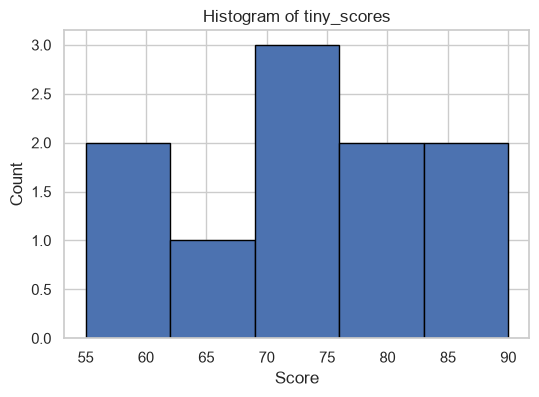

In [28]:
plt.figure(figsize=(6, 4))
plt.hist(tiny_scores, bins=5, edgecolor="black")
plt.title("Histogram of tiny_scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

A histogram groups values into **bins** (ranges) and counts how many values fall in each —
turning a column of numbers into a shape you can see at a glance.

### KDE plots — a smoothed version of the same idea

A **KDE (Kernel Density Estimate)** plot draws a smooth curve approximating the same shape a
histogram shows, without the "choppiness" that comes from bin-width choices.

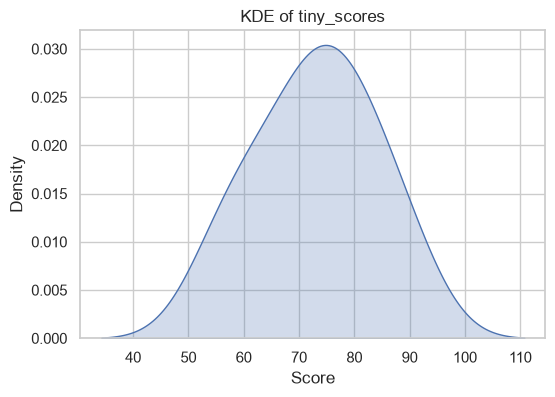

In [29]:
plt.figure(figsize=(6, 4))
sns.kdeplot(tiny_scores, fill=True)
plt.title("KDE of tiny_scores")
plt.xlabel("Score")
plt.show()

### Three shapes to recognize on sight

Let's generate three synthetic distributions and look at each one's shape and its mean/median
relationship.

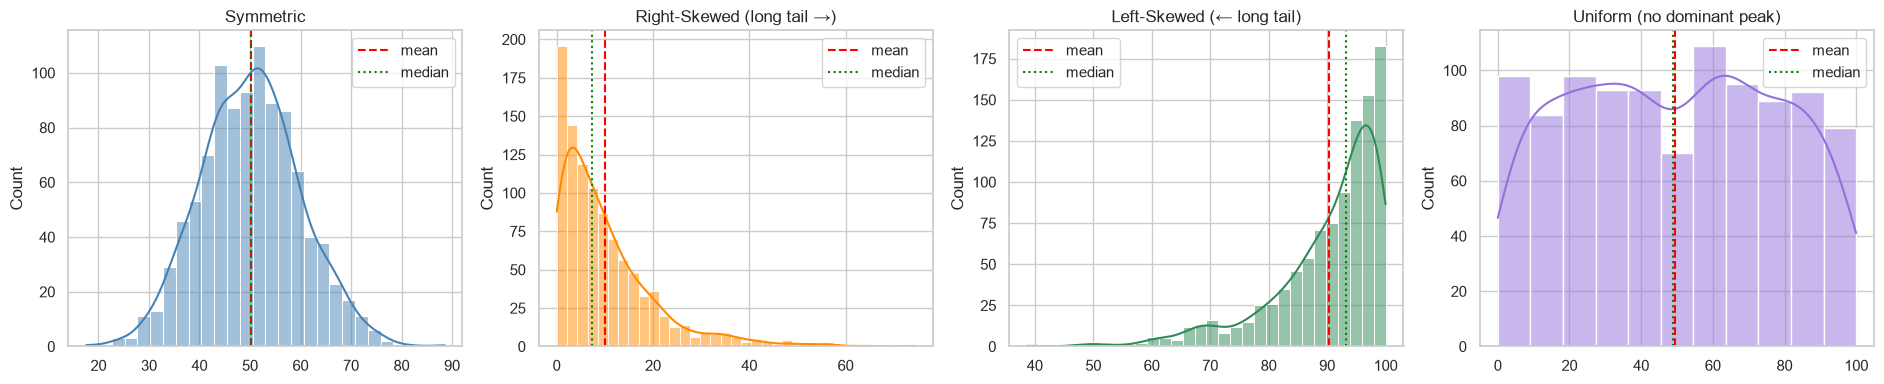

In [30]:
np.random.seed(42)

symmetric_data = np.random.normal(loc=50, scale=10, size=1000)          # classic bell curve
right_skewed_data = np.random.exponential(scale=10, size=1000)          # long tail to the RIGHT
left_skewed_data = 100 - np.random.exponential(scale=10, size=1000)     # long tail to the LEFT
uniform_data = np.random.uniform(low=0, high=100, size=1000)            # no dominant peak at all

fig, axes = plt.subplots(1, 4, figsize=(19, 4))

sns.histplot(symmetric_data, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Symmetric")
axes[0].axvline(np.mean(symmetric_data), color="red", linestyle="--", label="mean")
axes[0].axvline(np.median(symmetric_data), color="green", linestyle=":", label="median")
axes[0].legend()

sns.histplot(right_skewed_data, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Right-Skewed (long tail →)")
axes[1].axvline(np.mean(right_skewed_data), color="red", linestyle="--", label="mean")
axes[1].axvline(np.median(right_skewed_data), color="green", linestyle=":", label="median")
axes[1].legend()

sns.histplot(left_skewed_data, kde=True, ax=axes[2], color="seagreen")
axes[2].set_title("Left-Skewed (← long tail)")
axes[2].axvline(np.mean(left_skewed_data), color="red", linestyle="--", label="mean")
axes[2].axvline(np.median(left_skewed_data), color="green", linestyle=":", label="median")
axes[2].legend()

sns.histplot(uniform_data, kde=True, ax=axes[3], color="mediumpurple")
axes[3].set_title("Uniform (no dominant peak)")
axes[3].axvline(np.mean(uniform_data), color="red", linestyle="--", label="mean")
axes[3].axvline(np.median(uniform_data), color="green", linestyle=":", label="median")
axes[3].legend()

plt.tight_layout()
plt.show()


**The pattern to memorize, from the mean/median lines you just plotted:**
- **Symmetric** → mean ≈ median (both lines nearly overlap)
- **Right-skewed** (tail stretches right) → mean > median (a few large values pull the mean up)
- **Left-skewed** (tail stretches left) → mean < median (a few small values pull the mean down)
- **Uniform** → mean ≈ median too (it's symmetric), but there's no peak at all — every value is
  roughly equally likely. Don't confuse "mean ≈ median" with "normal"; uniform data satisfies
  that test but looks nothing like a bell curve.

This is the exact same phenomenon we saw numerically with `Fare` back in Section 3 — now you can
*see* why the mean sat above the median.

### On Titanic — `Fare` and `Age`

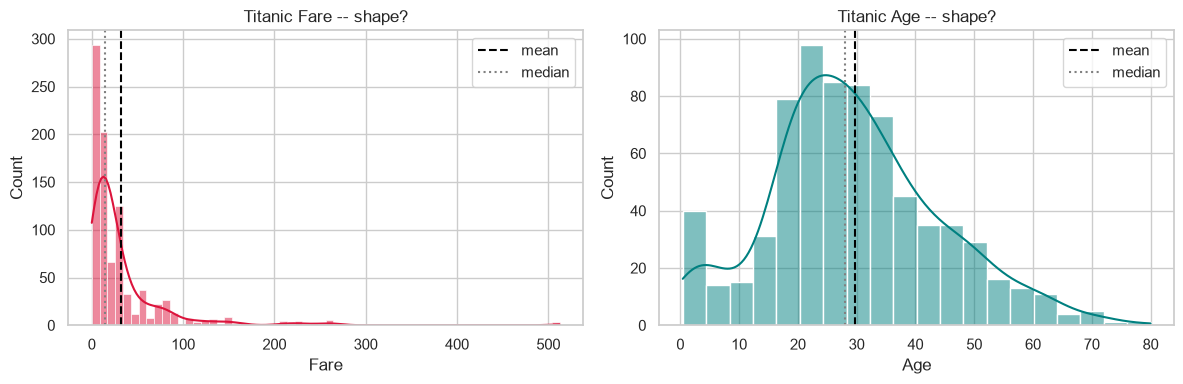

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(titanic["Fare"], kde=True, ax=axes[0], color="crimson")
axes[0].set_title("Titanic Fare -- shape?")
axes[0].axvline(titanic["Fare"].mean(), color="black", linestyle="--", label="mean")
axes[0].axvline(titanic["Fare"].median(), color="gray", linestyle=":", label="median")
axes[0].legend()

sns.histplot(titanic["Age"].dropna(), kde=True, ax=axes[1], color="teal")
axes[1].set_title("Titanic Age -- shape?")
axes[1].axvline(titanic["Age"].mean(), color="black", linestyle="--", label="mean")
axes[1].axvline(titanic["Age"].median(), color="gray", linestyle=":", label="median")
axes[1].legend()

plt.tight_layout()
plt.show()

### 💬 Discussion
Looking at the two charts above: which one is clearly right-skewed, and which one is much closer
to symmetric? Point to the specific visual evidence (tail direction, gap between mean and median
lines) that supports your answer — don't just guess from the titles.

### 🏋️ Student Practice
1. Plot a histogram with KDE overlay of `employees["Salary"]`. Given what you know about
   `Hossam`'s salary, what shape do you expect *before* running the cell?
2. Plot a histogram of `titanic["SibSp"]`. Is this more naturally read as a histogram (continuous
   shape) or would a different chart type (hint: Section 8) fit a discrete count column better?
   Explain your reasoning in a sentence.

In [32]:
# Your code here





### The Empirical Rule (68–95–99.7)

For data that's **approximately normal** (symmetric, bell-shaped, like `symmetric_data` above), there's a reliable rule of thumb:

- **~68%** of values fall within **±1 standard deviation** of the mean
- **~95%** of values fall within **±2 standard deviations** of the mean
- **~99.7%** of values fall within **±3 standard deviations** of the mean

This only holds for roughly-normal shapes — it breaks down on skewed data like `Fare`.

In [33]:
mean_s, std_s = symmetric_data.mean(), symmetric_data.std()

within_1sd = ((symmetric_data >= mean_s - std_s) & (symmetric_data <= mean_s + std_s)).mean()
within_2sd = ((symmetric_data >= mean_s - 2*std_s) & (symmetric_data <= mean_s + 2*std_s)).mean()
within_3sd = ((symmetric_data >= mean_s - 3*std_s) & (symmetric_data <= mean_s + 3*std_s)).mean()

print(f"Within ±1 SD: {within_1sd:.1%}  (rule says ~68%)")
print(f"Within ±2 SD: {within_2sd:.1%}  (rule says ~95%)")
print(f"Within ±3 SD: {within_3sd:.1%}  (rule says ~99.7%)")

Within ±1 SD: 68.6%  (rule says ~68%)
Within ±2 SD: 95.6%  (rule says ~95%)
Within ±3 SD: 99.7%  (rule says ~99.7%)


### On Titanic — does `Age` follow the rule?

`Age` is only *roughly* symmetric, so expect the rule to hold approximately, not exactly — unlike the synthetic `symmetric_data`, which was drawn from a true normal distribution.

In [34]:
age = titanic["Age"].dropna()
mean_age, std_age = age.mean(), age.std()

within_1sd_age = ((age >= mean_age - std_age) & (age <= mean_age + std_age)).mean()
within_2sd_age = ((age >= mean_age - 2*std_age) & (age <= mean_age + 2*std_age)).mean()

print(f"Titanic Age -- mean: {mean_age:.1f}, std: {std_age:.1f}")
print(f"Within ±1 SD ({mean_age - std_age:.1f}–{mean_age + std_age:.1f}): {within_1sd_age:.1%}  (rule says ~68%)")
print(f"Within ±2 SD ({mean_age - 2*std_age:.1f}–{mean_age + 2*std_age:.1f}): {within_2sd_age:.1%}  (rule says ~95%)")

Titanic Age -- mean: 29.7, std: 14.5
Within ±1 SD (15.2–44.2): 72.3%  (rule says ~68%)
Within ±2 SD (0.6–58.8): 95.9%  (rule says ~95%)


### ✅ Checkpoint
- Histograms and KDE plots reveal the *shape* numbers alone can hide. Symmetric: mean ≈ median.
  Right-skewed: mean > median, tail stretches right. Left-skewed: mean < median, tail stretches
  left. **Uniform**: no dominant peak, roughly flat across the range. You can often *predict* skew
  direction just from comparing mean and median, before ever plotting anything. For
  approximately normal data, the **Empirical Rule** (68-95-99.7) tells you what fraction of
  values fall within 1, 2, and 3 standard deviations of the mean.

---
## 7. Outlier Detection

**The question:** *"Which values don't belong — and how do I decide that objectively, instead of
just eyeballing a chart?"* We'll use two standard, complementary methods.

### Method 1 — The IQR Method

**Rule:** anything below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is flagged as an outlier. The
`1.5` multiplier is a long-standing statistical convention, not a law of nature — it's a
reasonable default, not the only valid choice.

In [35]:
def iqr_outlier_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

lower, upper = iqr_outlier_bounds(employees["Salary"])
print(f"IQR bounds for Salary: [{lower}, {upper}]")

iqr_outliers = employees[(employees["Salary"] < lower) | (employees["Salary"] > upper)]
iqr_outliers[["Name", "Salary"]]

IQR bounds for Salary: [4312.5, 11612.5]


,Name,Salary
9,Hossam,32000


### Method 2 — The Z-Score Method

**Rule:** the Z-score tells you how many standard deviations a value sits from the mean
(`z = (x - mean) / std`). A common convention: flag anything with `|z| > 3` as an outlier.

In [36]:
def z_scores(series):
    return (series - series.mean()) / series.std()

employees["Salary_zscore"] = z_scores(employees["Salary"])
employees[["Name", "Salary", "Salary_zscore"]].sort_values("Salary_zscore", ascending=False)

,Name,Salary,Salary_zscore
9,Hossam,32000,2.815436
6,Rana,9500,-0.081103
0,Sara,9000,-0.145471
2,Lina,8500,-0.209838
8,Salma,8100,-0.261332
4,Nourhan,7800,-0.299953
5,Khaled,7200,-0.377194
1,Omar,7000,-0.402941
3,Mostafa,6200,-0.505929
7,Ahmed,6000,-0.531676


In [37]:
z_outliers = employees[employees["Salary_zscore"].abs() > 3]
z_outliers[["Name", "Salary", "Salary_zscore"]]

,Name,Salary,Salary_zscore


### 🔮 Predict the Output
With a threshold of `|z| > 3`, do you expect `Hossam` to be flagged? What about with a looser
threshold of `|z| > 2`? Try both and see which one actually catches him.

In [38]:
print("Flagged with |z| > 3:", (employees['Salary_zscore'].abs() > 3).sum(), "employee(s)")
print("Flagged with |z| > 2:", (employees['Salary_zscore'].abs() > 2).sum(), "employee(s)")

Flagged with |z| > 3: 0 employee(s)
Flagged with |z| > 2: 1 employee(s)


With only 10 data points, `Hossam`'s one extreme value also drags the *mean and std themselves*
upward — a known limitation of Z-scores on small or already-skewed samples. This is worth
remembering: the outlier detection method itself isn't immune to the outliers it's trying to
detect.

### Visualizing outliers three ways

**Histogram** — outliers show up as isolated bars far from the main cluster.
**Box plot** — outliers are plotted as individual points beyond the "whiskers" (which extend to
`Q1 - 1.5*IQR` and `Q3 + 1.5*IQR` — literally the IQR method, drawn for you).
**Scatter plot** — outliers show up as points far from the rest of the cloud.

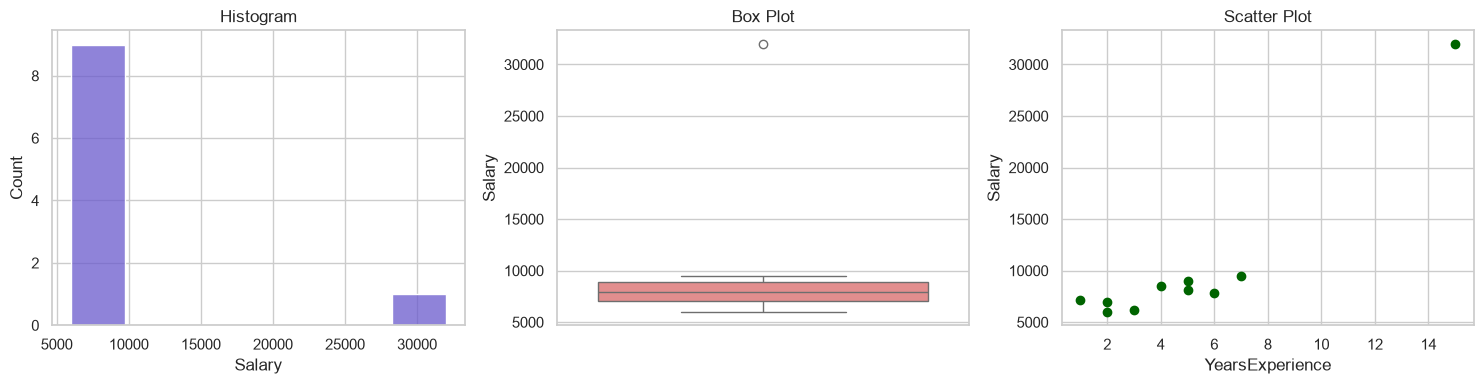

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(employees["Salary"], ax=axes[0], color="slateblue")
axes[0].set_title("Histogram")

sns.boxplot(y=employees["Salary"], ax=axes[1], color="lightcoral")
axes[1].set_title("Box Plot")

axes[2].scatter(employees["YearsExperience"], employees["Salary"], color="darkgreen")
axes[2].set_title("Scatter Plot")
axes[2].set_xlabel("YearsExperience")
axes[2].set_ylabel("Salary")

plt.tight_layout()
plt.show()

Notice the box plot draws `Hossam`'s salary as an isolated dot well above the top whisker —
that dot **is** the IQR method, visualized automatically by `seaborn`/`matplotlib` without you
computing bounds by hand.

### On Titanic — comparing both methods on `Fare`

In [40]:
fare_lower, fare_upper = iqr_outlier_bounds(titanic["Fare"])
fare_iqr_outliers = titanic[(titanic["Fare"] < fare_lower) | (titanic["Fare"] > fare_upper)]

fare_z = z_scores(titanic["Fare"])
fare_z_outliers = titanic[fare_z.abs() > 3]

print(f"IQR bounds: [{fare_lower:.2f}, {fare_upper:.2f}]")
print("IQR method flags     :", fare_iqr_outliers.shape[0], "passengers")
print("Z-score method flags :", fare_z_outliers.shape[0], "passengers")

IQR bounds: [-26.72, 65.63]
IQR method flags     : 116 passengers
Z-score method flags : 20 passengers


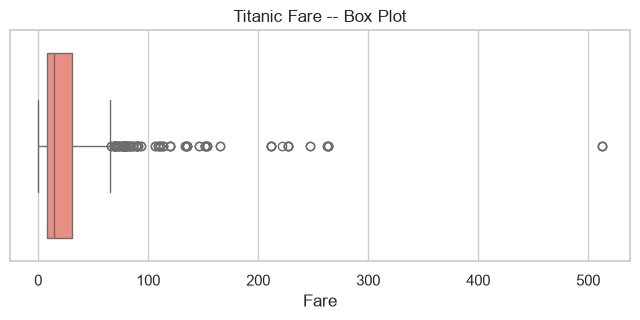

In [41]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=titanic["Fare"], color="salmon")
plt.title("Titanic Fare -- Box Plot")
plt.show()

### 💬 Discussion
The IQR method and the Z-score method flagged **different numbers** of outliers on `Fare`. Given
what you now know about `Fare` being right-skewed (Section 6), which method do you think is more
trustworthy here — one that assumes something close to a symmetric, bell-shaped distribution
(Z-score), or one based purely on rank position (IQR)? Why?

### 🏋️ Student Practice
1. Compute IQR-method outlier bounds for `titanic["Age"]` (careful — `.quantile()` on a column
   with missing values: check whether you need `.dropna()` first, and whether it changes your
   answer).
2. Compute Z-scores for `titanic["Age"]` and count how many passengers have `|z| > 3`.
3. Make a box plot of `Age` by `Pclass` (hint: `sns.boxplot(x="Pclass", y="Age", data=titanic)`)
   — does the spread of ages look similar across all three classes, or different?

In [42]:
# Your code here





### 🔥 Challenge Question
An outlier isn't automatically an *error*. `Hossam`'s salary might be entirely legitimate (a
director-level role) rather than a data-entry mistake. Propose one situation where you'd want to
**remove** a detected outlier before analysis, and one where you'd want to **keep** it — for each,
say what real-world context would make that the right call.

In [43]:
# Your answer here (as a comment, or convert this cell to Markdown)


### ✅ Checkpoint
- **IQR method**: flag anything outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` — robust, rank-based,
  works well even on skewed data. **Z-score method**: flag anything with `|z| > 3` — assumes a
  roughly symmetric distribution, and can itself be distorted by the very outliers it's looking
  for on small samples. Box plots visualize the IQR method directly. An outlier is a statistical
  fact, not automatically a data error — deciding what to do about one is a judgment call.

---
## 8. Data Visualization

We've already used Matplotlib and Seaborn a little, out of necessity. Let's now go through the
**core chart types** deliberately — for each one: when to use it, how to read it, and the most
common mistake people make with it.

**Matplotlib** is the low-level foundation — everything is built on it, and it gives you full
control. **Seaborn** is built on top of Matplotlib, and specializes in statistical charts with
much less code, especially when working with a `DataFrame` directly.

### Histogram — one numerical column's distribution
**When:** you want to see the shape of a single numerical variable.
**Read it:** tall bars = common value ranges; look at overall shape (symmetric/skewed) and any
isolated bars (possible outliers).
**Common mistake:** too few bins hides real structure; too many bins makes it noisy — there's no
single correct bin count, but it's worth trying a few.

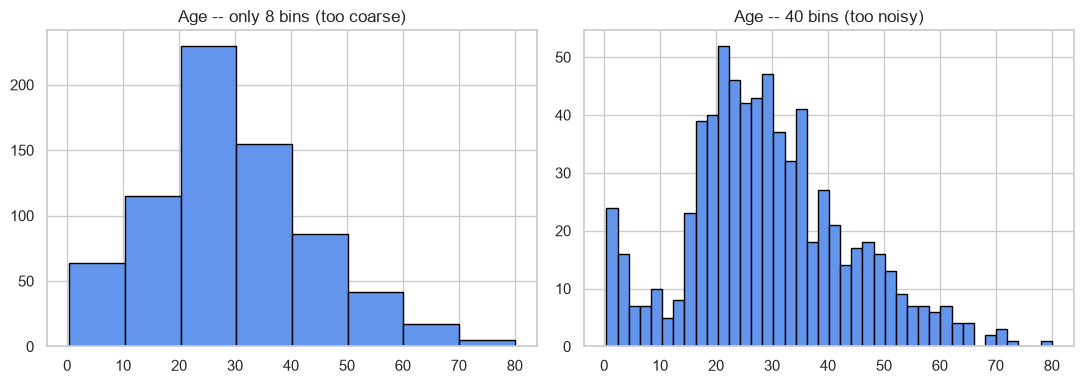

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(titanic["Age"].dropna(), bins=8, color="cornflowerblue", edgecolor="black")
axes[0].set_title("Age -- only 8 bins (too coarse)")

axes[1].hist(titanic["Age"].dropna(), bins=40, color="cornflowerblue", edgecolor="black")
axes[1].set_title("Age -- 40 bins (too noisy)")

plt.tight_layout()
plt.show()

### Box Plot — five-number summary + outliers, visually
**When:** you want spread, median, and outliers of a numerical column, especially **compared
across categories**.
**Read it:** the box is the IQR (Q1–Q3), the line inside is the median, whiskers extend to
`1.5*IQR`, dots beyond are outliers.
**Common mistake:** treating box plots as showing you the actual data density/shape — they don't
(a histogram or KDE does that); a box plot can look identical for very differently-shaped
distributions.

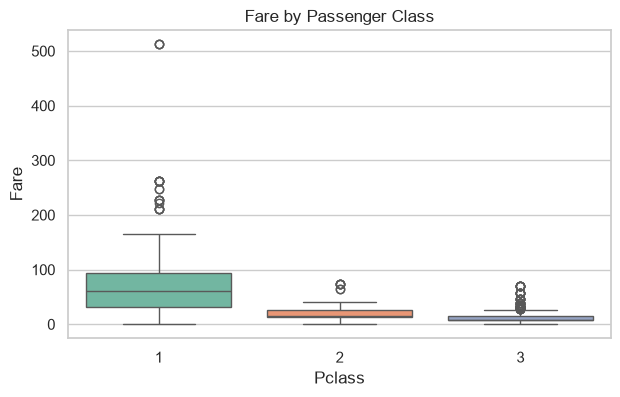

In [45]:
plt.figure(figsize=(7, 4))
sns.boxplot(x="Pclass", y="Fare", hue="Pclass", data=titanic, palette="Set2", legend=False)
plt.title("Fare by Passenger Class")
plt.show()

### Count Plot — frequency of each category
**When:** you want to count how many rows fall into each category of a **categorical** column.
**Read it:** bar height = count. Straightforward, but easy to mis-order categories.
**Common mistake:** using a count plot on a numerical column (you'd get one bar per unique value,
which is meaningless for something like `Fare`).

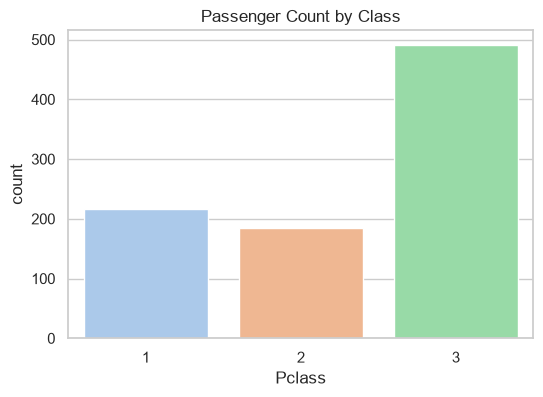

In [46]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Pclass", hue="Pclass", data=titanic, palette="pastel", legend=False)
plt.title("Passenger Count by Class")
plt.show()

### Bar Plot — a summary statistic per category
**When:** you want to compare a **computed statistic** (usually the mean, by default) across
categories — different from a count plot, which just counts rows.
**Read it:** bar height = the statistic (check the axis label!). Error bars (the thin vertical
lines) often show a confidence interval — don't ignore them.
**Common mistake:** confusing a bar plot (a computed statistic) with a count plot (a raw count) —
they look almost identical but answer different questions.

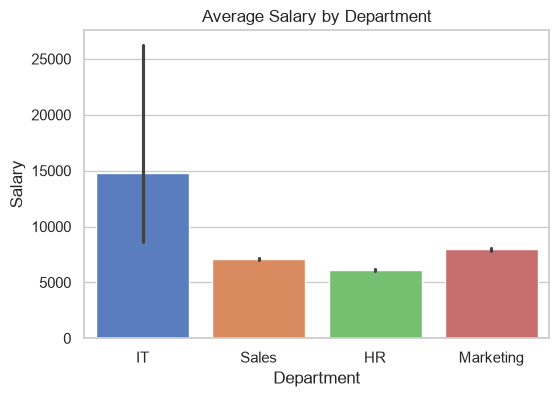

In [47]:
plt.figure(figsize=(6, 4))
sns.barplot(x="Department", y="Salary", hue="Department", data=employees, palette="muted", legend=False)
plt.title("Average Salary by Department")
plt.show()

### Scatter Plot — relationship between two numerical columns
**When:** you want to see if/how two numerical variables relate.
**Read it:** look for a trend (does one variable rise as the other does?), clusters, and outlier
points that sit apart from the main cloud.
**Common mistake:** assuming a visible pattern means *causation* — a scatter plot can show a
relationship exists, never *why*.

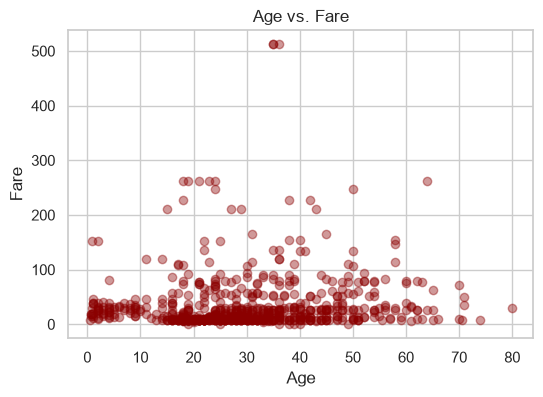

In [48]:
plt.figure(figsize=(6, 4))
plt.scatter(titanic["Age"], titanic["Fare"], alpha=0.4, color="darkred")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs. Fare")
plt.show()

### Line Plot — trend over an ordered sequence (usually time)
**When:** you have data ordered along some sequence (typically time) and want to show a trend.
**Read it:** direction and rate of change matter more than any single point.
**Common mistake:** using a line plot to connect points that have **no real order** (like
categories) — it implies a trend/connection that doesn't exist. Neither `employees` nor `titanic`
has a real time axis, so let's build a small illustrative example instead.

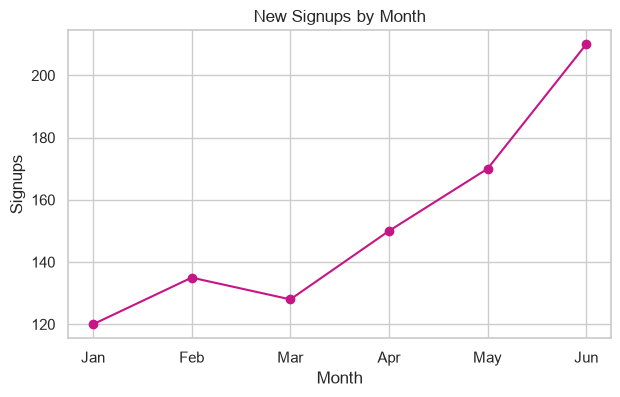

In [49]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
new_signups = [120, 135, 128, 150, 170, 210]

plt.figure(figsize=(7, 4))
plt.plot(months, new_signups, marker="o", color="mediumvioletred")
plt.title("New Signups by Month")
plt.xlabel("Month")
plt.ylabel("Signups")
plt.show()

### Heatmap — a matrix of values, encoded as color
**When:** you have a grid of numbers (very commonly a **correlation matrix**) and want to spot
patterns in color rather than scanning raw numbers.
**Read it:** color intensity = value magnitude; for a correlation heatmap, look for cells close
to `+1` (strong positive relationship) or `-1` (strong negative) — near `0` means little linear
relationship.
**Common mistake:** forgetting that correlation captures *linear* relationships only — two
variables can be strongly related in a curved way and still show a near-zero correlation.

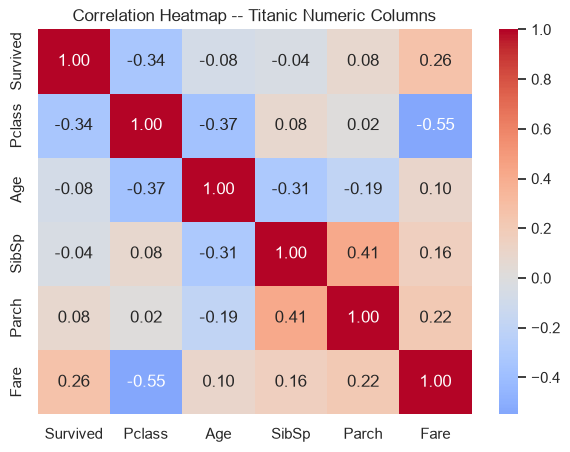

In [50]:
numeric_titanic = titanic[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]]
correlation_matrix = numeric_titanic.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap -- Titanic Numeric Columns")
plt.show()

### 🔮 Predict the Output
Before scrolling up to look again: do you expect `Pclass` and `Fare` to have a **positive** or
**negative** correlation? (Hint: remember `Pclass` is ordinal, with `1` = first class — the
*most* expensive class.)

### Pairplot — every numerical column against every other, at once
**When:** an early, broad look at relationships across several numerical variables simultaneously
— a fast way to spot which pairs deserve a closer scatter plot.
**Read it:** diagonal = each variable's own distribution; off-diagonal = pairwise scatter plots.
Adding `hue` lets you color by a categorical column, often revealing group differences instantly.
**Common mistake:** running it on a wide DataFrame with many columns — it gets slow and visually
overwhelming fast; keep it to a handful of relevant numeric columns.

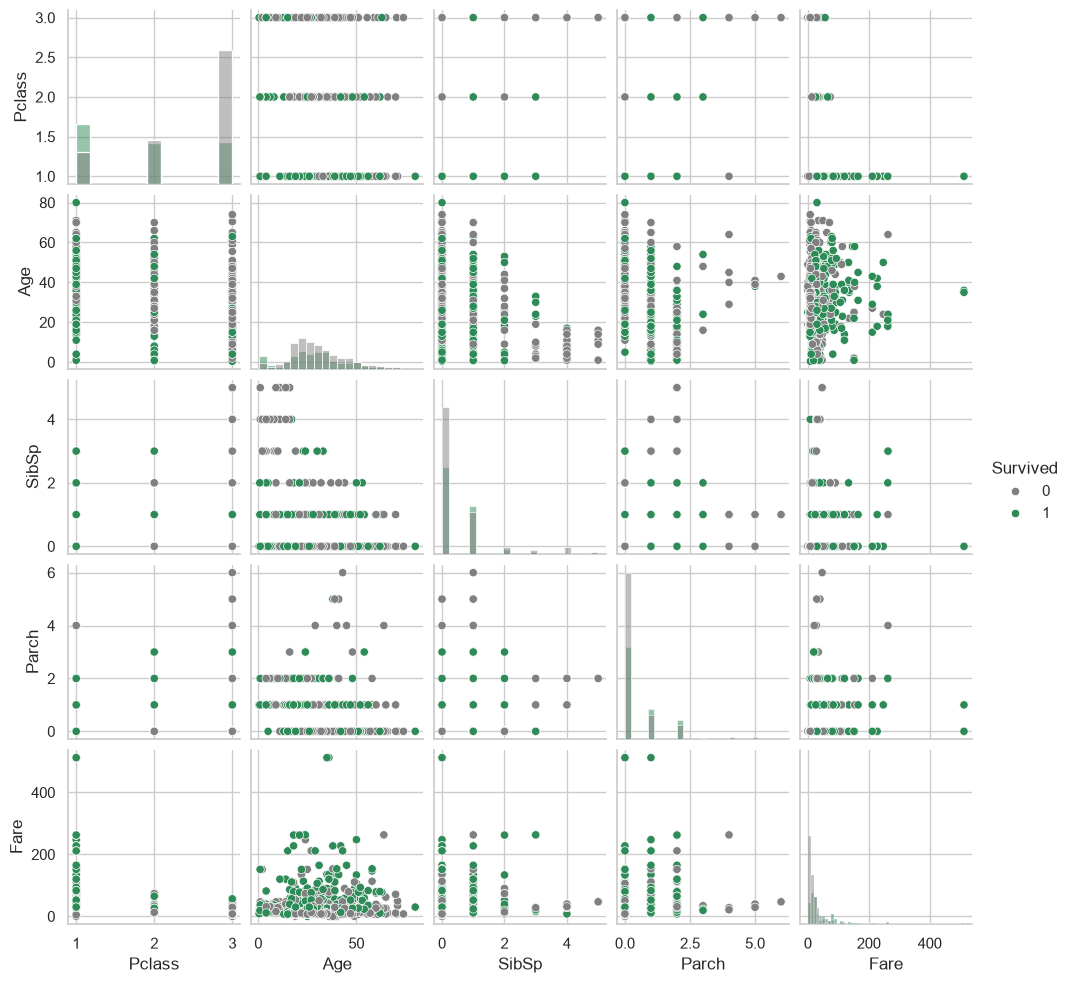

In [51]:
sns.pairplot(numeric_titanic.dropna(), hue="Survived", palette={0: "gray", 1: "seagreen"},
             diag_kind="hist", height=2.0)
plt.show()

### 🏋️ Student Practice
1. Make a count plot of `titanic["Sex"]`.
2. Make a bar plot of average `PerformanceScore` by `Department` in `employees`.
3. Make a scatter plot of `employees["YearsExperience"]` vs. `employees["Salary"]` — does more
   experience visually associate with higher salary here? Does `Hossam` distort your read of the
   trend?
4. Make a box plot of `titanic["Age"]` split by `Survived` (hint: `x="Survived", y="Age"`).

In [52]:
# Your code here





### ✅ Checkpoint
- Histogram/KDE → shape of one numerical column. Box plot → spread + outliers, great for
  comparing across categories. Count plot → frequency per category. Bar plot → a *statistic* per
  category (not a raw count). Scatter → relationship between two numerical columns. Line plot →
  trend over a genuinely ordered sequence. Heatmap → a matrix of values via color, most often a
  correlation matrix. Pairplot → every numeric pair at once, a fast first look.

---
## 9. Matplotlib Basics

We've been calling `plt.figure()`, `plt.title()`, and friends all lecture without naming what
they actually are. Let's slow down and look at the anatomy of a Matplotlib chart directly, so
you're in control of it rather than copy-pasting boilerplate.

### Figure vs. Axes

A **Figure** is the whole canvas/window. An **Axes** is one individual plot living inside that
figure (confusingly *not* the same as "axis," which refers to just the x or y line). One Figure
can contain multiple Axes — that's exactly what subplots are, coming up in Section 10.

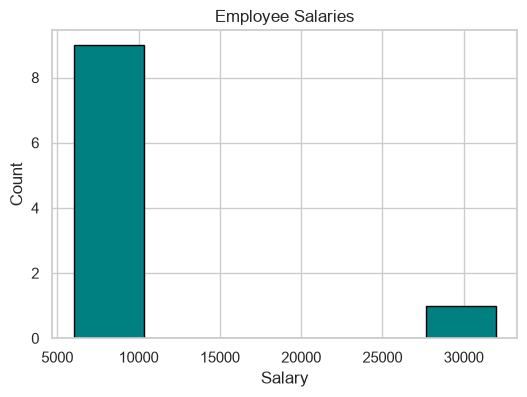

In [53]:
fig, ax = plt.subplots(figsize=(6, 4))     # ONE figure, ONE axes, explicitly created

ax.hist(employees["Salary"], bins=6, color="teal", edgecolor="black")
ax.set_title("Employee Salaries")
ax.set_xlabel("Salary")
ax.set_ylabel("Count")

plt.show()

### Figure size

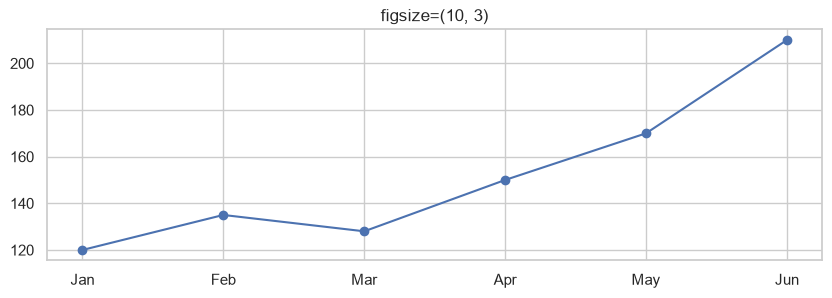

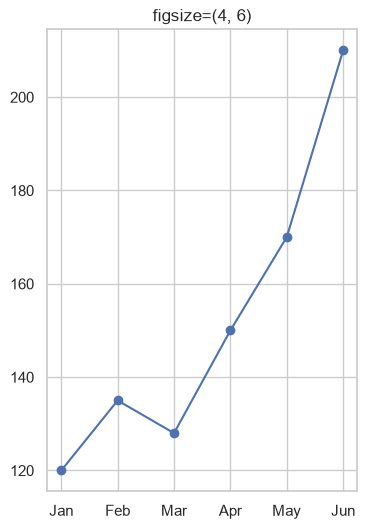

In [54]:
fig, ax = plt.subplots(figsize=(10, 3))    # wide and short, on purpose
ax.plot(months, new_signups, marker="o")
ax.set_title("figsize=(10, 3)")
plt.show()

fig, ax = plt.subplots(figsize=(4, 6))     # narrow and tall, on purpose
ax.plot(months, new_signups, marker="o")
ax.set_title("figsize=(4, 6)")
plt.show()

### Titles, labels, legends, grid, and colors — all together

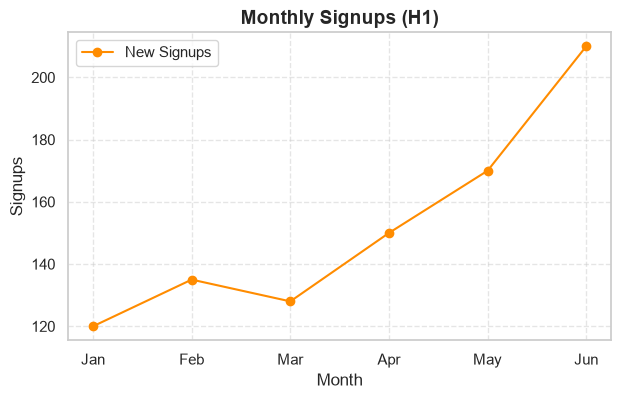

In [55]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(months, new_signups, marker="o", color="darkorange", label="New Signups")
ax.set_title("Monthly Signups (H1)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Signups")
ax.legend(loc="upper left")
ax.grid(True, linestyle="--", alpha=0.5)

plt.show()

### Annotations — pointing at something specific

`ax.annotate()` draws a label plus an optional arrow pointing at a specific data point — useful whenever a chart has *one* value the viewer's eye should land on first.

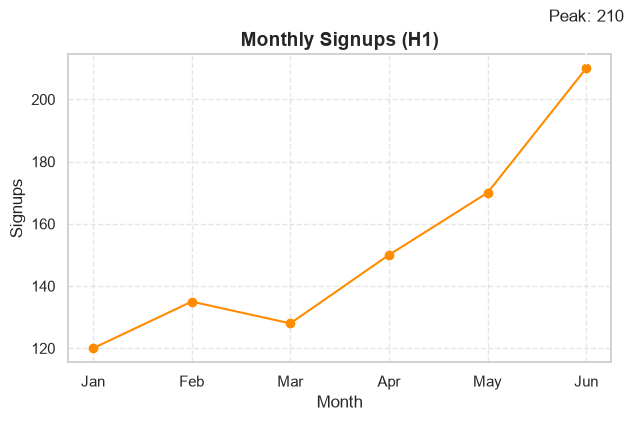

In [56]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(months, new_signups, marker="o", color="darkorange", label="New Signups")
ax.set_title("Monthly Signups (H1)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Signups")
ax.grid(True, linestyle="--", alpha=0.5)

peak_month = months[new_signups.index(max(new_signups))]
peak_value = max(new_signups)

ax.annotate(
    f"Peak: {peak_value}",
    xy=(peak_month, peak_value),                 # the point being annotated
    xytext=(peak_month, peak_value + 15),         # where the text sits
    ha="center",
    arrowprops=dict(facecolor="black", arrowstyle="->"),
)

plt.show()

### Saving figures

`plt.savefig()` writes the current figure to a file — call it **before** `plt.show()`, since
`show()` can clear the figure from memory afterward on some backends.

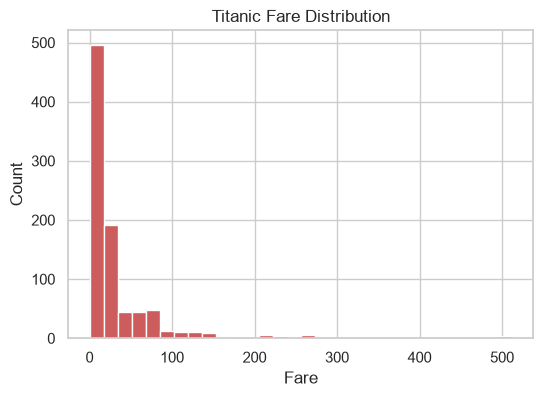

Saved fare_distribution.png


In [57]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(titanic["Fare"], bins=30, color="indianred")
ax.set_title("Titanic Fare Distribution")
ax.set_xlabel("Fare")
ax.set_ylabel("Count")

plt.savefig("fare_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fare_distribution.png")

### 🏋️ Student Practice
1. Create a figure of size `(8, 4)` showing a histogram of `titanic["Age"].dropna()`, with a
   title, x-label, and y-label.
2. Add a grid to your histogram.
3. Save your histogram to a file called `age_distribution.png`.

In [58]:
# Your code here





### ✅ Checkpoint
- A Figure is the canvas; an Axes is one plot within it. `figsize` controls overall dimensions.
  Titles/labels/legends/grid all attach to a specific Axes object once you create one explicitly
  with `plt.subplots()`. `savefig()` before `show()`.

---
## 10. Subplots

**The question:** *"I want several related charts side by side, not one at a time."* This is how
you build a small analytical dashboard.

### `subplot()` — the older, index-based way

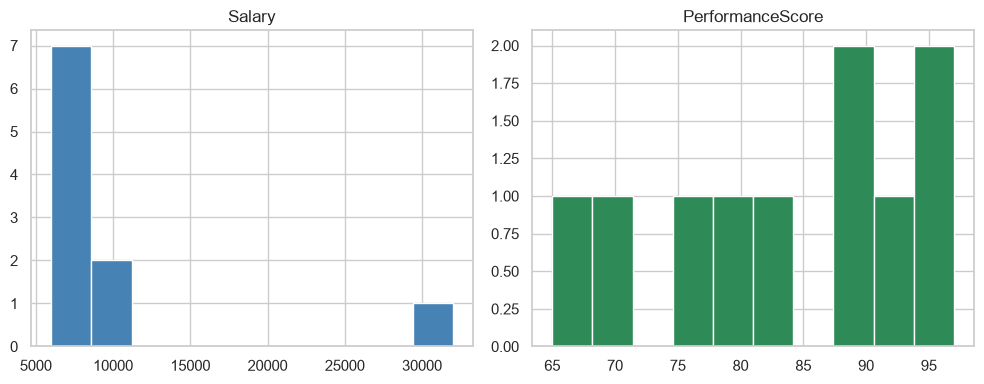

In [59]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)     # 1 row, 2 columns, THIS is plot #1
plt.hist(employees["Salary"], color="steelblue")
plt.title("Salary")

plt.subplot(1, 2, 2)     # 1 row, 2 columns, THIS is plot #2
plt.hist(employees["PerformanceScore"], color="seagreen")
plt.title("PerformanceScore")

plt.tight_layout()
plt.show()

### `subplots()` — the modern, recommended way

`plt.subplots(rows, cols)` returns **one Figure and a grid of Axes objects** all at once — this
is what we've been using since Section 6, and it's generally preferred because you get direct
handles to every individual Axes.

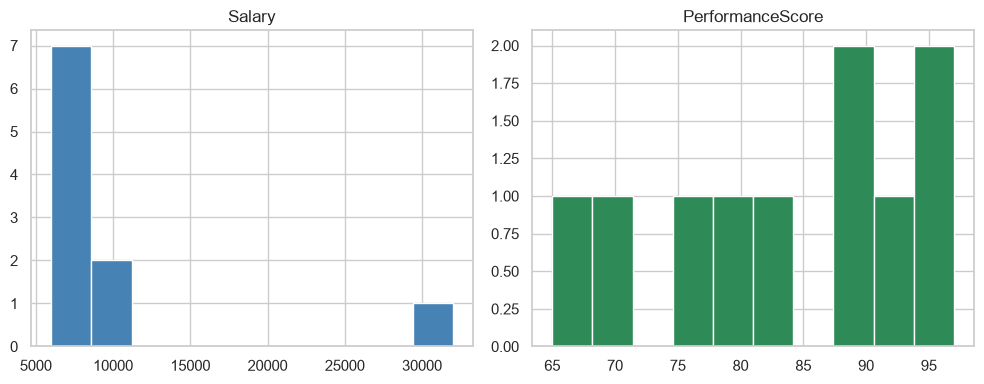

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(employees["Salary"], color="steelblue")
axes[0].set_title("Salary")

axes[1].hist(employees["PerformanceScore"], color="seagreen")
axes[1].set_title("PerformanceScore")

plt.tight_layout()
plt.show()

### A 2×2 grid, `suptitle()`, and `tight_layout()`

With a 2D grid of Axes, you index with `[row, col]`. `suptitle()` adds one title for the *whole*
figure (as opposed to each Axes' own `set_title()`). `tight_layout()` auto-adjusts spacing so
labels/titles don't overlap.

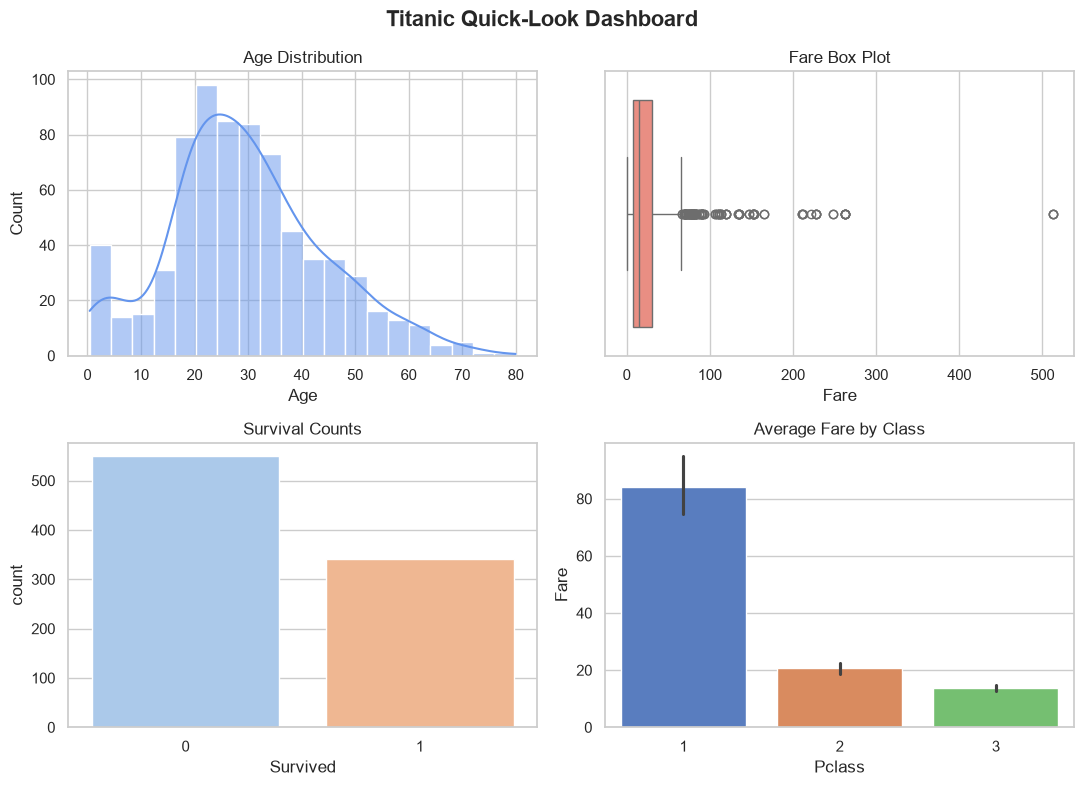

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

sns.histplot(titanic["Age"].dropna(), ax=axes[0, 0], color="cornflowerblue", kde=True)
axes[0, 0].set_title("Age Distribution")

sns.boxplot(x=titanic["Fare"], ax=axes[0, 1], color="salmon")
axes[0, 1].set_title("Fare Box Plot")

sns.countplot(x="Survived", hue="Survived", data=titanic, ax=axes[1, 0], palette="pastel", legend=False)
axes[1, 0].set_title("Survival Counts")

sns.barplot(x="Pclass", y="Fare", hue="Pclass", data=titanic, ax=axes[1, 1], palette="muted", legend=False)
axes[1, 1].set_title("Average Fare by Class")

fig.suptitle("Titanic Quick-Look Dashboard", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

That's a genuine small **dashboard** — four different, complementary views of the same
dataset, built entirely from tools you already know.

### 🏋️ Student Practice
Build your own 2×2 dashboard for the `employees` dataset, with `suptitle("Employees Dashboard")`:
1. Top-left: histogram of `Salary`
2. Top-right: box plot of `Salary`
3. Bottom-left: count plot of `Department`
4. Bottom-right: bar plot of average `PerformanceScore` by `Department`

In [62]:
# Your code here





### ✅ Checkpoint
- `plt.subplots(rows, cols)` is the modern way to build multi-chart figures, returning a Figure
  and a grid of Axes you index directly. `suptitle()` titles the whole figure; each Axes keeps
  its own `set_title()`. `tight_layout()` fixes overlapping labels — call it right before
  `show()`.

---
## 11. Seaborn Basics

We've been using Seaborn throughout — this section names what's actually available to you:
themes, palettes, and the `hue`/`style`/`size` parameters that make comparing groups almost
free.

### Themes and styles

We already set a theme at the very top of this notebook (`sns.set_theme(style="whitegrid")`).
Let's see a couple of others.

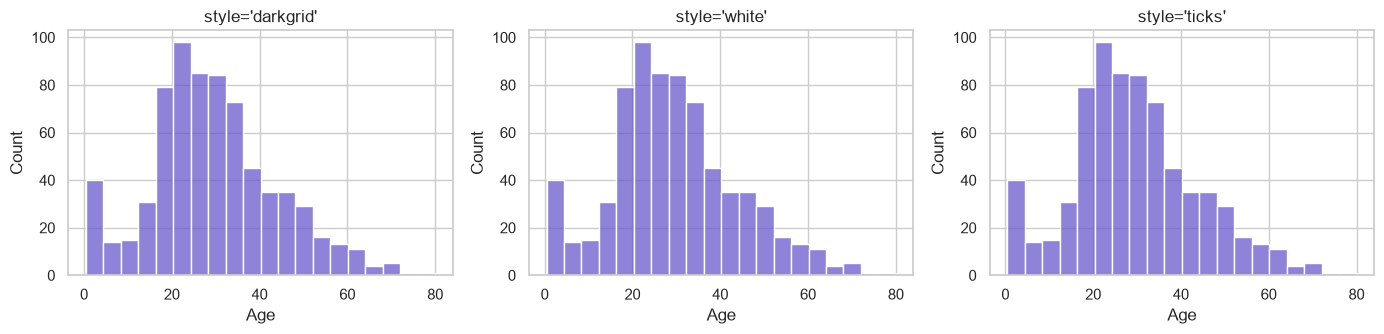

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for ax, style in zip(axes, ["darkgrid", "white", "ticks"]):
    with sns.axes_style(style):
        sns.histplot(titanic["Age"].dropna(), ax=ax, color="slateblue")
    ax.set_title(f"style='{style}'")

plt.tight_layout()
plt.show()

sns.set_theme(style="whitegrid")   # switch back to our default for the rest of the notebook

### Palettes — controlling color meaningfully

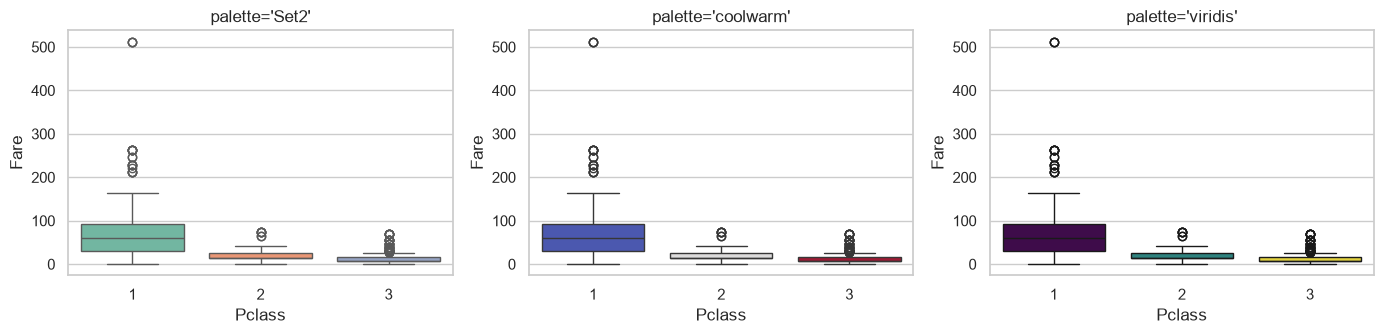

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for ax, palette in zip(axes, ["Set2", "coolwarm", "viridis"]):
    sns.boxplot(x="Pclass", y="Fare", hue="Pclass", data=titanic, ax=ax, palette=palette, legend=False)
    ax.set_title(f"palette='{palette}'")

plt.tight_layout()
plt.show()

**Choosing a palette isn't just decoration:** categorical palettes (like `Set2`) work best for
unordered categories; sequential/diverging palettes (like `coolwarm`, `viridis`) work best when
there's a meaningful order or a center point (like our correlation heatmap in Section 8).

### `hue` — adding a third (categorical) dimension to a 2D chart

This is arguably Seaborn's single most useful feature: color-coding points/bars by a category,
turning a 2-variable chart into a 3-variable one.

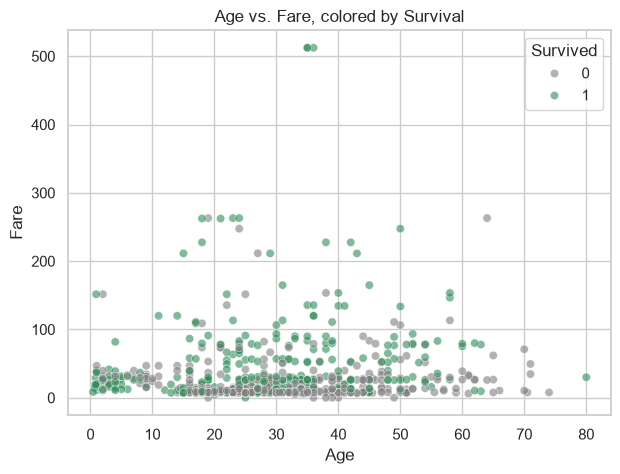

In [65]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x="Age", y="Fare", hue="Survived", data=titanic,
                palette={0: "gray", 1: "seagreen"}, alpha=0.6)
plt.title("Age vs. Fare, colored by Survival")
plt.show()

### 🔮 Predict the Output
Before running the next cell — do you expect the green (`Survived=1`) points to cluster more
toward higher `Fare` values, lower `Fare` values, or show no visible pattern at all?

### `style` and `size` — two more dimensions, if you need them

`style` changes marker shape per category; `size` scales marker size by a numerical column. Use
sparingly — stacking too many encodings (`hue` + `style` + `size` all at once) usually makes a
chart *harder* to read, not easier.

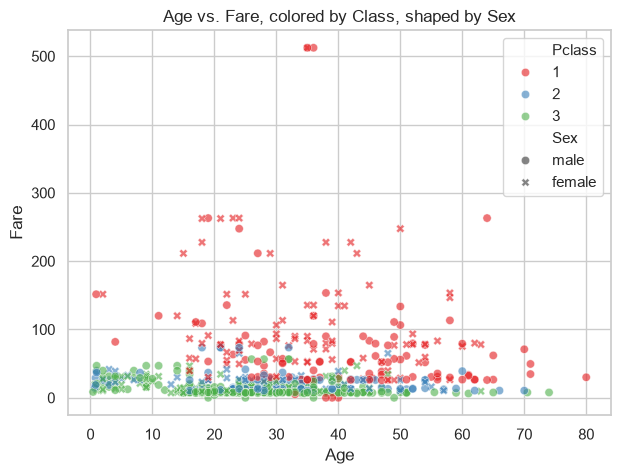

In [66]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x="Age", y="Fare", hue="Pclass", style="Sex", data=titanic,
                palette="Set1", alpha=0.6)
plt.title("Age vs. Fare, colored by Class, shaped by Sex")
plt.show()

### 🏋️ Student Practice
1. Make a box plot of `Salary` by `Department` in `employees`, using the `"pastel"` palette.
2. Make a scatter plot of `Age` vs. `Fare` in `titanic`, with `hue="Pclass"` instead of
   `hue="Survived"`. Does a different pattern jump out compared to the survival-colored version?
3. Try a count plot of `titanic["Pclass"]` with `hue="Survived"` — what does this reveal that a
   plain count plot of `Pclass` alone wouldn't?

In [67]:
# Your code here





### ✅ Checkpoint
- `sns.set_theme()` / `axes_style()` control overall look. Palettes should match the data:
  categorical for unordered groups, sequential/diverging for ordered or centered data. `hue` adds
  a categorical dimension via color — often the single highest-value addition you can make to a
  chart. `style`/`size` add more dimensions, but stack them sparingly.

---
## 12. Reading Charts

You've now *built* a lot of charts. This section is deliberately different: **no new chart
types** — just slowing down to genuinely interpret ones you've already made. This is arguably the
most important section in the notebook: the whole point of a chart is the insight you pull out of
it, not the code that drew it.

For every chart below, work through the same four questions:
- **What does this chart tell us?**
- **Is the data skewed?**
- **Are there outliers?**
- **Is there a relationship?** (if applicable)
- **What insight can we extract?**

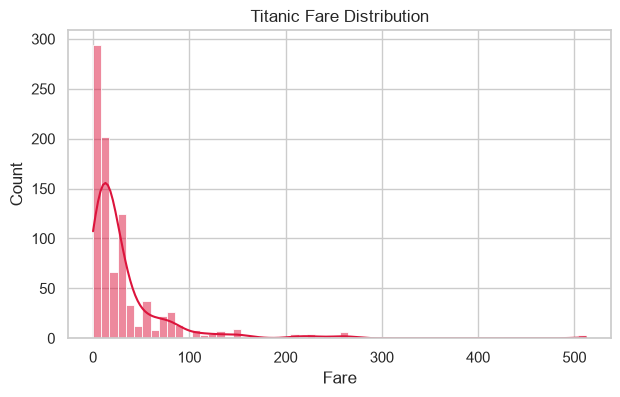

In [68]:
plt.figure(figsize=(7, 4))
sns.histplot(titanic["Fare"], kde=True, color="crimson")
plt.title("Titanic Fare Distribution")
plt.show()

### 💬 Discussion — Fare Distribution
- What does this chart tell us? *(shape, where most values cluster)*
- Is the data skewed? Which direction, and how do you know from the shape alone?
- Are there outliers? Where do they sit relative to the main cluster?
- What insight can we extract about ticket pricing on the Titanic?

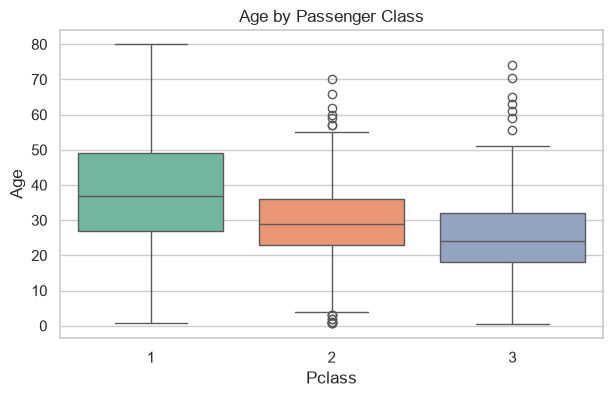

In [69]:
plt.figure(figsize=(7, 4))
sns.boxplot(x="Pclass", y="Age", hue="Pclass", data=titanic, palette="Set2", legend=False)
plt.title("Age by Passenger Class")
plt.show()

### 💬 Discussion — Age by Class
- What does this chart tell us about each class's typical age?
- Which class has the widest spread of ages? The narrowest?
- Are there outliers in any class specifically?
- What might explain an age difference between classes, historically?

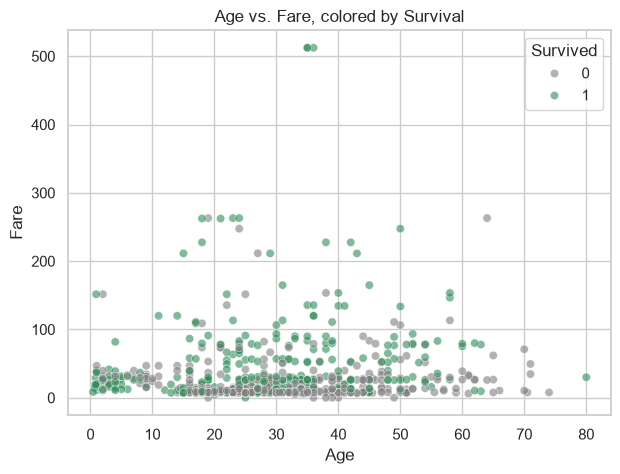

In [70]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x="Age", y="Fare", hue="Survived", data=titanic,
                palette={0: "gray", 1: "seagreen"}, alpha=0.6)
plt.title("Age vs. Fare, colored by Survival")
plt.show()

### 💬 Discussion — Age vs. Fare vs. Survival
- Is there a visible relationship between `Age` and `Fare`? How strong does it look?
- Where do the green (survived) points concentrate, if anywhere?
- Are there any outlier points, and do they tend to be survivors or not?
- What insight can we extract, combining all three variables at once?

### 🏋️ Student Practice
Pick any **two** charts you built earlier in this notebook (Sections 8–11) that you haven't
discussed yet. For each, write 2–3 sentences answering the same four questions above.

In [71]:
# Write your interpretations here as markdown-style comments, or convert this cell to Markdown.





### ✅ Checkpoint
- A chart without interpretation is just decoration. Every chart you build should be able to
  answer: *what's the shape, is it skewed, are there outliers, is there a relationship, and what
  does that actually mean?* That's the difference between making charts and doing analysis.

---
## 13. Titanic Practice

Time to bring every idea from today together, independently, the way you'll work on real data
going forward. We're **not** doing full EDA here (that's next lecture) — just applying today's
statistical and visual toolkit, end to end, on your own.

**This section is yours.** Work through the tasks in order — each builds naturally on the last.
We'll finish with a class discussion, so keep notes on anything that surprises you.

### Your tasks

1. **Central tendency**: compute the mean, median, and mode of `Fare`. Compare mean vs. median —
   what does the gap tell you (callback to Section 3)?
2. **Spread**: compute the `std()` of `Fare`, and separately, the `std()` of `Fare` **grouped by
   `Pclass`**. Which class has the most variable fares?
3. **Quartiles**: compute the five-number summary of `Age`. What's the IQR?
4. **Outlier detection**: use **both** the IQR method and the Z-score method to detect outliers
   in `Fare`. How many does each method flag? Do the two methods roughly agree?
5. **Distribution shape**: plot a histogram with KDE of `Age`. Is it closer to symmetric or
   skewed? Compare it to the `Fare` histogram from Task 1 (or re-plot it) — which one is more
   skewed, and how can you tell just from the shape?
6. **Multiple charts**: build a 2×2 subplot dashboard (`suptitle`, `tight_layout`) containing:
   - a histogram of `Age`
   - a box plot of `Fare` by `Pclass`
   - a count plot of `Survived`
   - a scatter plot of `Age` vs. `Fare`, colored (`hue`) by `Survived`
7. **Interpretation**: for **each** of the 4 charts in your dashboard, write 1–2 sentences
   answering: what does it show, is anything skewed, are there outliers, and what's one insight
   you can pull out of it?

Work through these in order — each builds naturally on the last, the same way today's lecture
did.

In [ ]:
# Your work starts here.
# Task 1: Central tendency
fare = titanic["Fare"]

print("Mean:", fare.mean())
print("Median:", fare.median())
print("Mode:")
print(fare.mode())

Mean: 32.204207968574636
Median: 14.4542
Mode:
0    8.05
Name: Fare, dtype: float64


In [ ]:
# Task 2: Spread
print("Overall Fare Standard Deviation:")
print(titanic["Fare"].std())

print("\nStandard Deviation by Pclass:")
print(titanic.groupby("Pclass")["Fare"].std())

Overall Standard Deviation:
49.6934285971809

Standard Deviation by Pclass:
Pclass
1    78.380373
2    13.417399
3    11.778142
Name: Fare, dtype: float64


In [82]:
# Task 3: Quartiles
age = titanic["Age"].dropna()

print(age.describe())

Q1 = age.quantile(0.25)
Q3 = age.quantile(0.75)

IQR = Q3 - Q1

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64
Q1 = 20.125
Q3 = 38.0
IQR = 17.875


In [83]:
# Task 4: Outlier detection (IQR and Z-score)

from scipy.stats import zscore
Q1 = fare.quantile(0.25)
Q3 = fare.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

iqr_outliers = fare[(fare < lower) | (fare > upper)]

print("IQR Outliers:", len(iqr_outliers))

z = zscore(fare)

z_outliers = fare[abs(z) > 3]

print("Z-score Outliers:", len(z_outliers))




IQR Outliers: 116
Z-score Outliers: 20


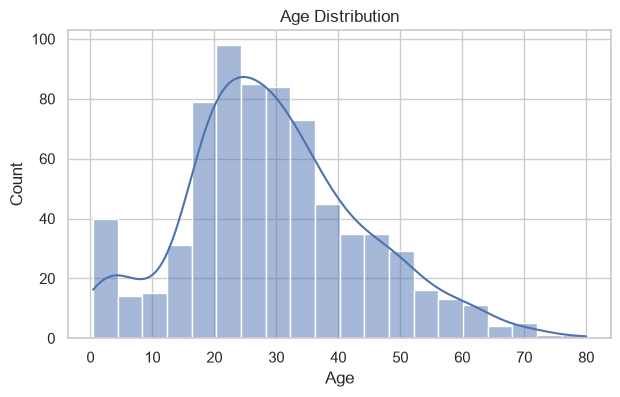

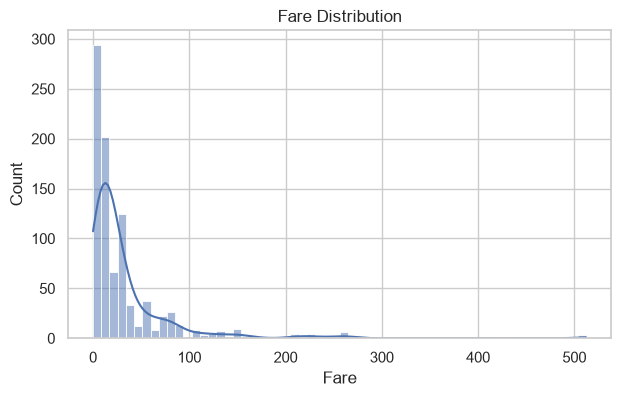

In [85]:
# Task 5: Distribution shape
plt.figure(figsize=(7,4))

sns.histplot(titanic["Age"].dropna(), kde=True)

plt.title("Age Distribution")

plt.show()

plt.figure(figsize=(7,4))

sns.histplot(titanic["Fare"], kde=True)

plt.title("Fare Distribution")

plt.show()



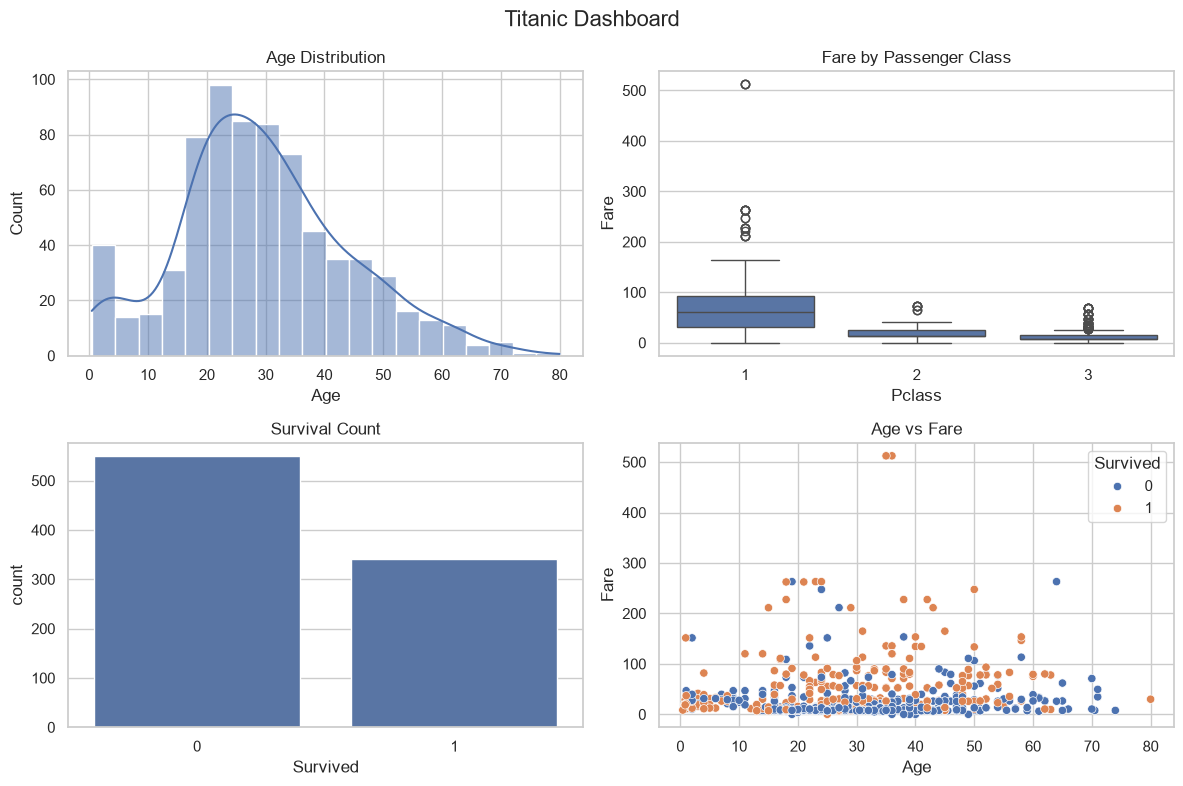

In [ ]:
# Task 6: Multiple charts -- 2x2 dashboard

fig, axes = plt.subplots(2,2, figsize=(12,8))

sns.histplot(titanic["Age"].dropna(), kde=True, ax=axes[0,0])
axes[0,0].set_title("Age Distribution")

sns.boxplot(x="Pclass", y="Fare", data=titanic, ax=axes[0,1])
axes[0,1].set_title("Fare by Passenger Class")

sns.countplot(x="Survived", data=titanic, ax=axes[1,0])
axes[1,0].set_title("Survival Count")

sns.scatterplot(x="Age",y="Fare",hue="Survived",data=titanic, ax=axes[1,1])
axes[1,1].set_title("Age vs Fare")

fig.suptitle("Titanic Dashboard", fontsize=16)

plt.tight_layout()

plt.show()



### Task 7: Interpretation

Write your interpretation of each of your 4 dashboard charts here (or as markdown/comments in the
cell below):

1. **Age histogram:**
2. **Fare by Pclass box plot:**
3. **Survived count plot:**
4. **Age vs. Fare scatter (colored by Survived):**

In [87]:
# Optional: any supporting code for your interpretations

# 1. Age Histogram:
# The age distribution is slightly right-skewed,
# most passengers were between 20 and 40 years old. There are noo utliers
# most passengers were young and adults.

# 2. Fare by Pclass (Box Plot):
# First-class passengers generally paid much higher fares than passengers
# The plot also shows several high-fare outliers especially in first class.

# 3. Survival Count Plot:
# More passengers did not survive than survived, showing an imbalanced distribution.
# The disaster resulted in a high overall mortality rate.

# 4. Age vs. Fare Scatter Plot:
# No strong relationship between age and fare.
# passengers who paid higher fares appear to have a higher survival rate.





### 💬 Class discussion

Once you've worked through the tasks above, be ready to discuss:
- Which single statistic (mean, median, std, IQR, or an outlier count) told you the most about
  this dataset, and why?
- Between the IQR method and the Z-score method, which did you trust more for `Fare` specifically
  — and would your answer change for a more symmetric column like `Age`?
- Looking at your full dashboard: if you had to pick **one** chart to show a non-technical
  stakeholder to explain "who survived the Titanic and why," which would it be, and why?
- What questions do these charts raise that they *can't* answer — the kind of thing full EDA,
  next lecture, would need to dig into further?

---
## Wrap-up

Today you moved from "I can manipulate data" to "I can understand what data is telling me" —
on both a small teaching dataset and the real Titanic dataset:
- Classified data as numerical/categorical, continuous/discrete, nominal/ordinal
- Computed and correctly chose between mean, median, and mode — and saw how outliers distort each
  differently
- Computed variance, standard deviation, quartiles, the IQR, and the five-number summary
- Recognized symmetric, right-skewed, and left-skewed distributions, and connected each shape to
  the relationship between its mean and median
- Detected outliers with both the IQR method and the Z-score method, and compared their
  trade-offs
- Built histograms, box plots, count plots, bar plots, scatter plots, line plots, heatmaps, and
  pairplots — in both Matplotlib and Seaborn
- Practiced Matplotlib fundamentals (Figure vs. Axes, titles, labels, legends, saving) and
  built multi-chart dashboards with subplots
- Used Seaborn's themes, palettes, and `hue`/`style`/`size` to add dimensions to a chart
- Most importantly: practiced **reading** every chart like an analyst, not just producing it

**Next time:** full Exploratory Data Analysis (EDA) — we'll take every tool from today and use it
end-to-end to actually *investigate* a dataset and answer real questions with it.